# Cell-Cycle Scoring and Regression

In [1]:
library(Seurat)
library(tidyverse)

Attaching SeuratObject

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# A list of cell cycle markers, from Tirosh et al, 2015, is loaded with Seurat.  We can
# segregate this list into markers of G2/M phase and markers of S phase
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.genes

In [15]:
FL.integrated <- readRDS("output/K12345678_integrated.rds")

In [16]:
FL.cc <- CellCycleScoring(FL.integrated, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)

# view cell cycle scores and phase assignments
head(FL.cc[[]])

Warning message:
“The following features are not present in the object: PRIM1, MLF1IP, RPA2, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: FAM64A, HN1, not searching for symbol synonyms”


,orig.ident,nCount_RNA,nFeature_RNA,S.Score,G2M.Score,Phase,old.ident
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<fct>
AAACCTGAGATCACGG-1_1,K1B,3273,1471,-0.09951926,-0.1272296,G1,K1B
AAACCTGAGCCAGTTT-1_1,K1B,5993,1886,-0.14177542,-0.1630444,G1,K1B
AAACCTGAGCGGCTTC-1_1,K1B,6318,2544,0.03804129,-0.1515221,S,K1B
AAACCTGAGGCATGTG-1_1,K1B,3102,1317,-0.11601894,-0.0826755,G1,K1B
AAACCTGAGTGTTTGC-1_1,K1B,2582,1179,-0.06735561,-0.1861788,G1,K1B
AAACCTGCAACTGCTA-1_1,K1B,2894,1236,0.07778758,-0.1302206,S,K1B


Picking joint bandwidth of 0.0105

Picking joint bandwidth of 0.0181

Picking joint bandwidth of 0.00846

Picking joint bandwidth of 0.0221



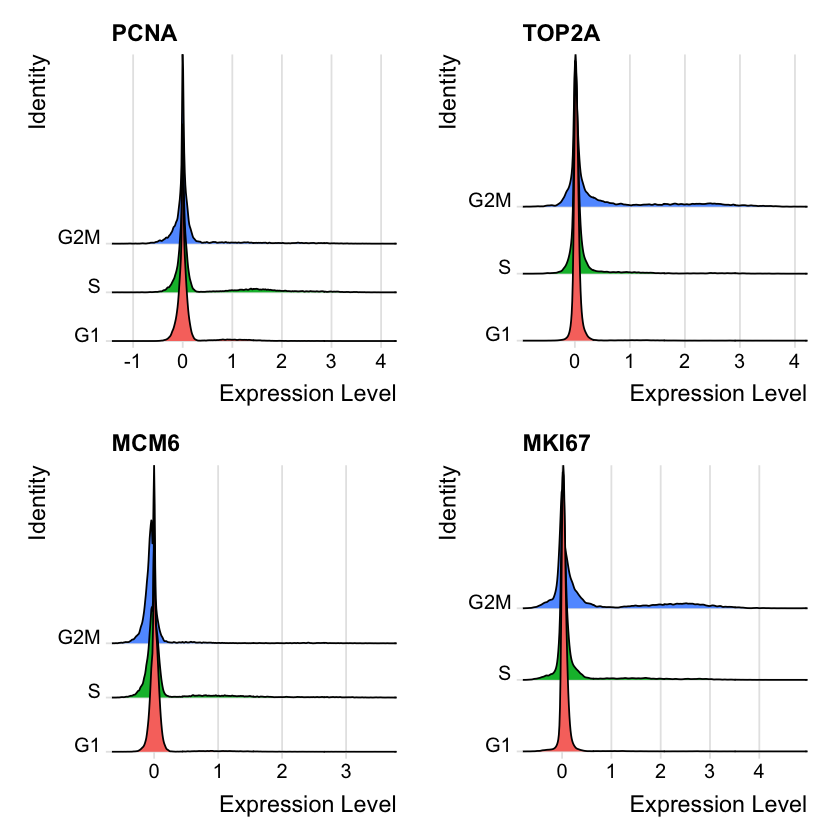

In [30]:
# Visualize the distribution of cell cycle markers across
RidgePlot(FL.cc, features = c("PCNA", "TOP2A", "MCM6", "MKI67"), ncol = 2)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 5 features requested have not been scaled (running reduction without them): PRIM1, MLF1IP, RPA2, FAM64A, HN1”
Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
PC_ 1 
Positive:  GTSE1, CENPF, AURKB, NUF2, MKI67, UBE2C, BIRC5, CDCA3, CDCA8, RRM2 
	   CDC20, TOP2A, TYMS, CCNB2, TPX2, CENPA, CKS1B, NUSAP1, HMGB2, HMMR 
	   CENPE, CDK1, CKAP2L, CDC25C, TUBB4B, CLSPN, CDCA2, HJURP, PSRC1, AURKA 
Negative:  BLM, UNG, CASP8AP2, TIPIN, UBR7, WDR76, POLA1, BRIP1, LBR, MSH2 
	   G2E3, CDCA7, CHAF1B, MCM6, MCM5, GAS2L3, CCNE2, RFC2, CTCF, TTK 
	   DSCC1, MCM2, SLBP, POLD3, EXO1, NASP, KIF20B, RANGAP1, DTL, HELLS 
PC_ 2 
Positive:  PSRC1, CDC20, CCNB2, NEK2, CENPA, HMMR, AURKA, CENPE, CENPF, CDCA8 
	   TOP2A, UBE2C, NUF2, DLGAP5, CDC25C, BUB1, KIF23, HJURP, GAS2L3, TPX2 
	   CKAP2L, BIRC5, CKAP2

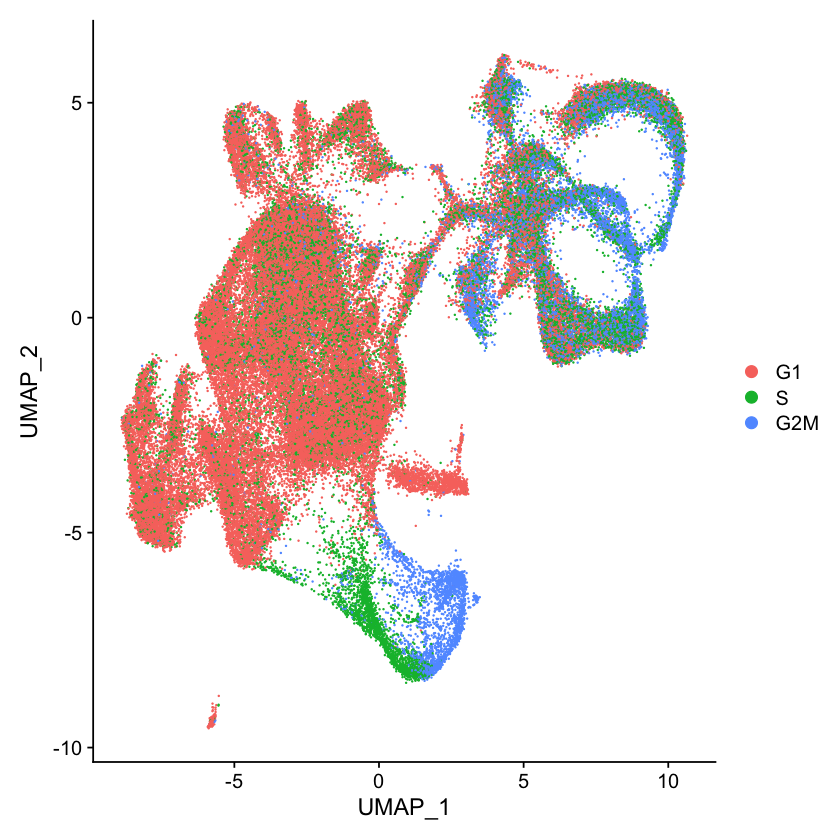

In [31]:
# Running a PCA on cell cycle genes reveals, unsurprisingly, that cells separate entirely by
# phase
FL.cc.pca <- RunPCA(FL.cc, features = c(s.genes, g2m.genes))
DimPlot(FL.cc.pca)

In [20]:
cell_cycle <- as.data.frame(FL.cc[[]]) %>% tibble::rownames_to_column("cell") %>% mutate(cell = gsub(".{4}$", "", cell))

In [22]:
#write.csv(cell_cycle, "output/FL_cell_cycle.csv", row.names=FALSE)

In [3]:
cell_cycle <- read.csv("output/FL_cell_cycle.csv")

In [23]:
### Load df with filtered SHMss events (trully positive)
df_summary <- read.csv("output/df_summary_K12345678_v3.csv")

In [24]:
pos_cells <- df_summary %>% mutate(orig.ident = str_sub(subject, 1, 3), group = "SHMss_observed") %>% select(orig.ident,cell,group) %>% unique()
head(pos_cells)

,orig.ident,cell,group
,<chr>,<chr>,<chr>
1,K1B,AGCTTGACAATGGACG,SHMss_observed
3,K1B,CTAGCCTCAATCACAC,SHMss_observed
4,K1B,CGAGCACAGGTTCCTA,SHMss_observed
5,K1B,ATCATGGGTGGTCTCG,SHMss_observed
6,K1B,TCTTTCCGTCTAGTCA,SHMss_observed
7,K1B,ACGCCAGAGGCATTGG,SHMss_observed


In [25]:
my_cells <- read.csv("output/reference_cell_strict_v3.csv") %>% rename(orig.ident=experiment) %>% bind_rows(pos_cells)
head(my_cells)

,orig.ident,cell,group
,<chr>,<chr>,<chr>
1,K1B,AAACCTGTCGGCTTGG,SHMss_not_observed
2,K1B,ACGTCAAAGAGCCCAA,SHMss_not_observed
3,K1B,ACGTCAACATTGAGCT,SHMss_not_observed
4,K1B,ACTGAACCATCAGTCA,SHMss_not_observed
5,K1B,ATCCACCAGTACCGGA,SHMss_not_observed
6,K1B,ATGTGTGTCTTCAACT,SHMss_not_observed


In [26]:
table(my_cells$group)


SHMss_not_observed     SHMss_observed 
              3596                364 

In [27]:
FL_cc <- inner_join(cell_cycle, my_cells) #%>% unique()
head(FL_cc)

Joining with `by = join_by(cell, orig.ident)`


,cell,orig.ident,nCount_RNA,nFeature_RNA,S.Score,G2M.Score,Phase,old.ident,group
,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<fct>,<chr>
1,AAACCTGTCGGCTTGG,K1B,6626,2122,-0.067851845,-0.13448421,G1,K1B,SHMss_not_observed
2,AACCGCGAGGTGCTAG,K1B,5302,2208,-0.111318745,-0.11980086,G1,K1B,SHMss_observed
3,AACTCAGCATTCGACA,K1B,4059,1949,-0.025713892,-0.04474254,G1,K1B,SHMss_observed
4,AAGGTTCGTTGTACAC,K1B,2885,1453,-0.067106075,-0.07278863,G1,K1B,SHMss_observed
5,ACACCAAGTCCTGCTT,K1B,2590,1305,-0.105854797,-0.05304949,G1,K1B,SHMss_not_observed
6,ACACCCTCACACCGCA,K1B,3573,1758,0.008015704,-0.03481795,S,K1B,SHMss_observed


In [28]:
str(FL_cc)

'data.frame':	3960 obs. of  9 variables:
 $ cell        : chr  "AAACCTGTCGGCTTGG" "AACCGCGAGGTGCTAG" "AACTCAGCATTCGACA" "AAGGTTCGTTGTACAC" ...
 $ orig.ident  : chr  "K1B" "K1B" "K1B" "K1B" ...
 $ nCount_RNA  : num  6626 5302 4059 2885 2590 ...
 $ nFeature_RNA: int  2122 2208 1949 1453 1305 1758 1665 1770 1852 2111 ...
 $ S.Score     : num  -0.0679 -0.1113 -0.0257 -0.0671 -0.1059 ...
 $ G2M.Score   : num  -0.1345 -0.1198 -0.0447 -0.0728 -0.053 ...
 $ Phase       : chr  "G1" "G1" "G1" "G1" ...
 $ old.ident   : Factor w/ 8 levels "K1B","K2B","K3B",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ group       : chr  "SHMss_not_observed" "SHMss_observed" "SHMss_observed" "SHMss_observed" ...


- Transcriptional events during S-phase are critical for cell cycle progression. Here, by using a nascent RNA capture assay coupled with high-throughput sequencing, we determined the temporal patterns of transcriptional events that occur during S-phase.
- During the G1 phase, cells accomplish most of their growth. They get bigger in size and make proteins and organelles needed for normal functions of DNA synthesis. Here, proteins and RNAs are synthesized, and, more especially the centromere and the other components of the centrosomes are made

In [33]:
FL_cc %>% filter( group == "SHMss_observed") %>%  select(Phase) %>% table()

Phase
 G1 G2M   S 
285  25  54 

In [34]:
FL_cc %>% filter( group == "SHMss_not_observed") %>%  select(Phase) %>% table()

Phase
  G1  G2M    S 
2501  286  809 

In [41]:
FL_cc_summary <- FL_cc %>% group_by(group, Phase) %>% count() %>% group_by(group) %>% mutate(percentage= n * 100 / sum(n))
FL_cc_summary

group,Phase,n,percentage
<chr>,<chr>,<int>,<dbl>
SHMss_not_observed,G1,2501,69.549499
SHMss_not_observed,G2M,286,7.953281
SHMss_not_observed,S,809,22.497219
SHMss_observed,G1,285,78.296703
SHMss_observed,G2M,25,6.868132
SHMss_observed,S,54,14.835165


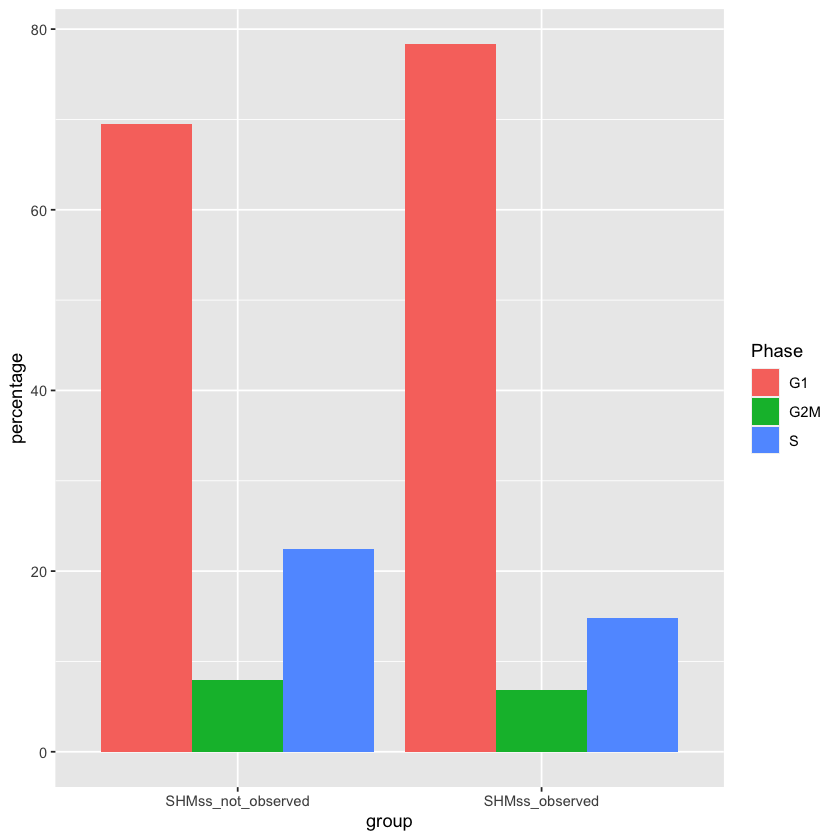

In [42]:
# Use position=position_dodge()
ggplot(data=FL_cc_summary, aes(x=group, y=percentage, fill=Phase)) +
geom_bar(stat="identity", position=position_dodge())